# EduSpark: A Big Data Framework for Student Performance Analytics
## Use Case 1 - Student Performance Analytics System

This notebook presents the final results and evaluation from the cleaned CSV-only Spark analytics outputs produced for the EduSpark 5-file student performance analytics pipeline.

## Configuration

- High-performing threshold: 85
- Low-performing threshold: 60
- Fail threshold: 40
- Attendance-risk threshold: 65

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
project_root = Path.cwd()
if not (project_root / "outputs").exists() and (project_root.parent / "outputs").exists():
    project_root = project_root.parent

avg_subject_path = project_root / "outputs/analytics/average_marks_by_subject_csv"
avg_semester_path = project_root / "outputs/analytics/average_marks_by_semester_csv"
high_perf_path = project_root / "outputs/analytics/high_performing_students_csv"
low_perf_path = project_root / "outputs/analytics/low_performing_students_csv"
at_risk_path = project_root / "outputs/analytics/at_risk_students_csv"
overview_path = project_root / "outputs/analytics/analytics_overview.csv"

required_paths = [avg_subject_path, avg_semester_path, high_perf_path, low_perf_path, at_risk_path, overview_path]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    missing_list = "\n".join(str(path.relative_to(project_root)) for path in missing_paths)
    raise FileNotFoundError(
        "Analytics outputs are missing. Run scripts/generate_data.py, scripts/preprocess.py, and scripts/analytics.py first.\n"
        f"Missing:\n{missing_list}"
    )

In [ ]:
def load_spark_csv_folder(folder_path):
    folder_path = Path(folder_path)
    csv_files = sorted(folder_path.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {folder_path}")
    return pd.read_csv(csv_files[0])

# analytics_overview.csv is written as a regular CSV file and is loaded directly with pandas.

In [ ]:
avg_subject_df = load_spark_csv_folder(avg_subject_path)
avg_semester_df = load_spark_csv_folder(avg_semester_path)
high_perf_df = load_spark_csv_folder(high_perf_path)
low_perf_df = load_spark_csv_folder(low_perf_path)
at_risk_df = load_spark_csv_folder(at_risk_path)
overview_df = pd.read_csv(overview_path)

for column in ["average_mark", "student_count", "record_count"]:
    if column in avg_subject_df.columns:
        avg_subject_df[column] = pd.to_numeric(avg_subject_df[column], errors="coerce")

for column in ["year", "semester", "average_mark", "student_count", "record_count"]:
    if column in avg_semester_df.columns:
        avg_semester_df[column] = pd.to_numeric(avg_semester_df[column], errors="coerce")

for df in [high_perf_df, low_perf_df, at_risk_df]:
    for column in ["overall_average_score", "overall_attendance_percentage", "course_count", "failed_courses"]:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors="coerce")

if "value" in overview_df.columns:
    overview_df["value"] = pd.to_numeric(overview_df["value"], errors="coerce")

## Data Preview

The notebook first confirms that the final CSV output files were loaded correctly before moving into the results and evaluation sections.

In [ ]:
display(overview_df)
display(avg_subject_df.head())
display(avg_semester_df.head())

,metric,value
0,total_students,10000
1,total_courses,150
2,total_enrollments,240927
3,total_grade_summary_records,240843
4,total_attendance_summary_records,240927
5,high_performing_students,2521
6,low_performing_students,1
7,at_risk_students,6256


,course_id,course_name,department,average_mark,student_count,record_count
0,COURSE91,Open-source Zero-defect Paradigm,Physics,81.01,1385,1631
1,COURSE2,Course 2,Physics,81.00,1364,1603
2,COURSE120,Inverse Web-enabled Infrastructure,Physics,80.78,1410,1635
3,COURSE20,Course 20,Computer Science,80.74,1244,1430
4,COURSE124,Fundamental Empowering Hierarchy,Biology,80.73,1322,1503


,year,semester,average_mark,student_count,record_count
0,2022,1,80.30,10000,30397
1,2022,2,80.35,10000,29989
2,2023,1,80.35,10000,30111
3,2023,2,80.36,10000,30165
4,2024,1,80.39,10000,30197


## Average Marks by Subject

,course_id,course_name,department,average_mark,student_count
0,COURSE91,Open-source Zero-defect Paradigm,Physics,81.01,1385
1,COURSE2,Course 2,Physics,81.00,1364
2,COURSE120,Inverse Web-enabled Infrastructure,Physics,80.78,1410
3,COURSE20,Course 20,Computer Science,80.74,1244
4,COURSE124,Fundamental Empowering Hierarchy,Biology,80.73,1322
5,COURSE117,Synergistic Upward-trending Focus Group,Physics,80.73,1443
6,COURSE4,Course 4,Biology,80.70,1350
7,COURSE92,Proactive Upward-trending Emulation,Physics,80.68,1401
8,COURSE25,Course 25,Biology,80.67,1374
9,COURSE75,Grass-roots Next Generation Task-force,Biology,80.66,1290


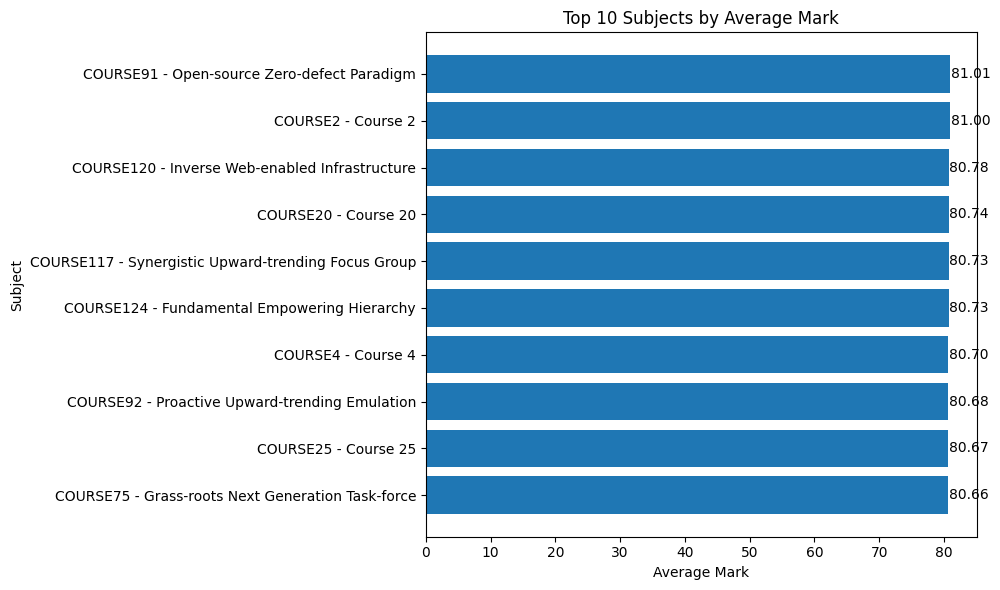

In [ ]:
subject_top_10 = (
    avg_subject_df
    .sort_values("average_mark", ascending=False)
    [["course_id", "course_name", "department", "average_mark", "student_count"]]
    .head(10)
)

display(subject_top_10)

subject_chart_df = (
    subject_top_10
    .assign(subject_label=lambda df: df["course_id"] + " - " + df["course_name"])
    .sort_values("average_mark", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(subject_chart_df["subject_label"], subject_chart_df["average_mark"])
plt.xlabel("Average Mark")
plt.ylabel("Subject")
plt.title("Top 10 Subjects by Average Mark")
for index, value in enumerate(subject_chart_df["average_mark"]):
    plt.text(value + 0.05, index, f"{value:.2f}", va="center")
plt.tight_layout()
plt.show()

The top subject averages are tightly clustered, with the current top five ranging from 80.73 to 81.01. Physics, Computer Science, and Biology appear in the leading subjects, supporting department-level comparison without changing the final threshold logic.

## Average Marks by Semester

,year,semester,average_mark,student_count,record_count,period
0,2022,1,80.30,10000,30397,2022-S1
1,2022,2,80.35,10000,29989,2022-S2
2,2023,1,80.35,10000,30111,2023-S1
3,2023,2,80.36,10000,30165,2023-S2
4,2024,1,80.39,10000,30197,2024-S1
5,2024,2,80.32,10000,30012,2024-S2
6,2025,1,80.36,10000,30026,2025-S1
7,2025,2,80.38,10000,29946,2025-S2


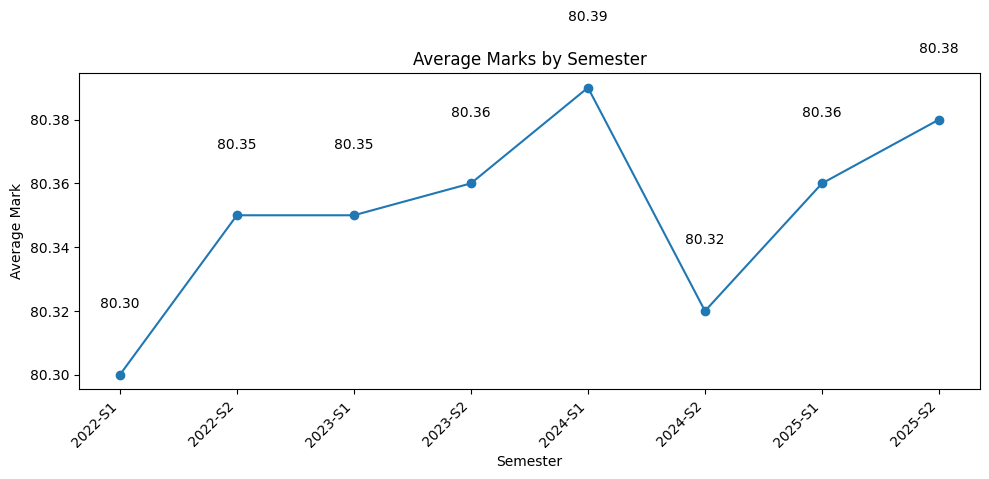

In [ ]:
semester_table = (
    avg_semester_df
    .sort_values(["year", "semester"])
    [["year", "semester", "average_mark", "student_count", "record_count"]]
    .reset_index(drop=True)
)

semester_table["period"] = (
    semester_table["year"].astype(int).astype(str)
    + "-S"
    + semester_table["semester"].astype(int).astype(str)
)

display(semester_table)

plt.figure(figsize=(10, 5))
plt.plot(semester_table["period"], semester_table["average_mark"], marker="o")
plt.xlabel("Semester")
plt.ylabel("Average Mark")
plt.title("Average Marks by Semester")
for index, value in enumerate(semester_table["average_mark"]):
    plt.text(index, value + 0.02, f"{value:.2f}", ha="center", va="bottom")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Semester averages are stable across all eight periods from 2022-S1 through 2025-S2, ranging from 80.30 to 80.39. This suggests that the overall academic performance profile remains consistent over time rather than changing sharply between cohorts.

## Student Performance Classification

,classification,count
0,High-performing students,2521
1,Low-performing students,1
2,At-risk students,6256


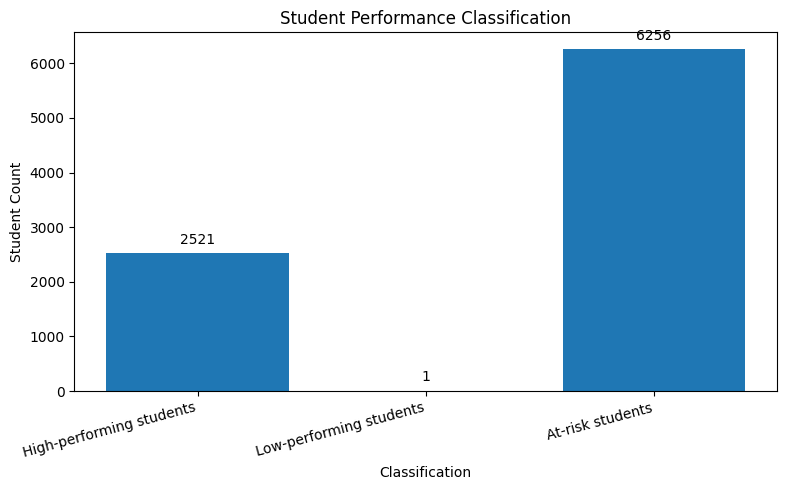

In [ ]:
overview_counts = overview_df.set_index("metric")["value"].to_dict()

classification_counts = pd.DataFrame(
    {
        "classification": [
            "High-performing students",
            "Low-performing students",
            "At-risk students",
        ],
        "count": [
            int(overview_counts.get("high_performing_students", len(high_perf_df))),
            int(overview_counts.get("low_performing_students", len(low_perf_df))),
            int(overview_counts.get("at_risk_students", len(at_risk_df))),
        ],
    }
)

display(classification_counts)

plt.figure(figsize=(8, 5))
bars = plt.bar(classification_counts["classification"], classification_counts["count"])
plt.xlabel("Classification")
plt.ylabel("Student Count")
plt.title("Student Performance Classification")
plt.xticks(rotation=15, ha="right")
label_offset = classification_counts["count"].max() * 0.02
for bar, value in zip(bars, classification_counts["count"]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + label_offset, f"{int(value)}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

The final counts show 2,521 high-performing students, 1 low-performing student, and 6,256 at-risk students. High-performing students form a substantial group, low-performing students are rare, and the at-risk population remains important for targeted intervention because attendance is below the final risk threshold for many students.

## Top and Bottom Student Profiles

In [ ]:
student_profile_columns = [
    "student_id",
    "full_name",
    "major",
    "overall_average_score",
    "overall_attendance_percentage",
    "failed_courses",
]

top_students = (
    high_perf_df
    .sort_values("overall_average_score", ascending=False)
    [student_profile_columns]
    .head(10)
)

bottom_students = (
    low_perf_df
    .sort_values("overall_average_score", ascending=True)
    [student_profile_columns]
    .head(10)
)

print("Top-performing student profiles")
display(top_students)

print("Low-performing student profiles")
display(bottom_students)

Top-performing student profiles


,student_id,full_name,major,overall_average_score,overall_attendance_percentage,failed_courses
0,1917,Matthew Gaines,Mathematics,94.93,67.09,0
1,10569,Chamara Abeysekera,Computer Science,94.70,71.72,0
2,7692,Piumi Silva,Biology,94.56,77.82,0
3,5156,Supun Ranatunga,Mathematics,94.53,72.47,0
4,5346,Tharindu Senanayake,Physics,94.40,73.18,0
5,3127,Lahiru Jayasinghe,Physics,94.37,72.37,0
6,6476,Tharindu Wijesinghe,Biology,94.36,75.98,0
7,10284,Kavindi Jayasinghe,Computer Science,94.23,74.66,0
8,5188,Hiruni Senanayake,Biology,94.18,72.70,0
9,5719,Ayesh Madushanka,Mathematics,93.99,74.88,0


Low-performing student profiles


,student_id,full_name,major,overall_average_score,overall_attendance_percentage,failed_courses
0,4490,Supun Ekanayake,Physics,58.97,53.67,0


Top students combine strong overall marks with generally good attendance, which reinforces their placement in the high-performing group. The current low-performing output contains one student below the final low-performing threshold, suggesting that the simulated distribution is weighted toward moderate to strong academic outcomes.

## Academic Risk Analysis

,student_id,full_name,major,overall_average_score,overall_attendance_percentage,failed_courses,risk_reasons
0,4490,Supun Ekanayake,Physics,58.97,53.67,0,Low average score; Low attendance
1,6825,Tharushi Rajapaksha,Biology,60.38,55.59,0,Low attendance
2,9437,Tharindu Ranatunga,Mathematics,60.82,53.42,0,Low attendance
3,4782,Rashmi Madushanka,Biology,60.91,54.81,0,Low attendance
4,5233,Kasun Senanayake,Computer Science,60.95,54.27,0,Low attendance
5,5323,Piumi Peiris,Biology,61.01,53.21,0,Low attendance
6,7796,Madhavi Peiris,Computer Science,61.54,48.73,0,Low attendance
7,8653,Rashmi Ekanayake,Computer Science,61.64,51.35,0,Low attendance
8,8891,Madhavi Ranatunga,Physics,61.68,61.99,0,Low attendance
9,5637,Dinithi Peiris,Physics,61.76,55.44,0,Low attendance


,risk_factor,count
0,Low attendance,6256
1,Low average score,1


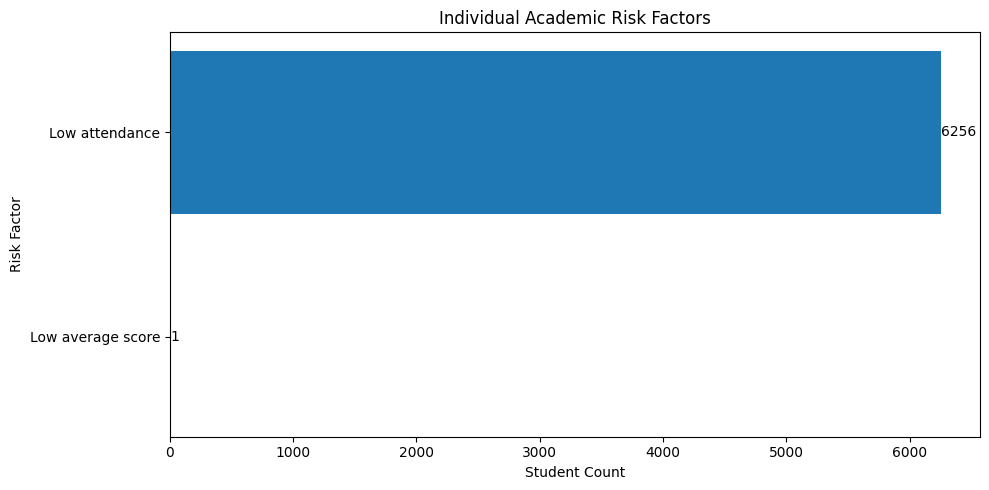

In [ ]:
risk_columns = [
    "student_id",
    "full_name",
    "major",
    "overall_average_score",
    "overall_attendance_percentage",
    "failed_courses",
    "risk_reasons",
]

display(at_risk_df[risk_columns].head(10))

risk_factor_counts = (
    at_risk_df["risk_reasons"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

risk_factor_counts = (
    risk_factor_counts[risk_factor_counts != ""]
    .value_counts()
    .rename_axis("risk_factor")
    .reset_index(name="count")
)

display(risk_factor_counts)

plt.figure(figsize=(10, 5))
risk_factor_chart = risk_factor_counts.sort_values("count", ascending=True)
plt.barh(risk_factor_chart["risk_factor"], risk_factor_chart["count"])
plt.xlabel("Student Count")
plt.ylabel("Risk Factor")
plt.title("Individual Academic Risk Factors")
for index, value in enumerate(risk_factor_chart["count"]):
    plt.text(value + 0.5, index, f"{int(value)}", va="center")
plt.tight_layout()
plt.show()

Low attendance is the dominant risk factor in the final dataset. The current at-risk output contains 6,255 students flagged for low attendance only and 1 student flagged for both low average score and low attendance.

## Final Findings

- 150 subject summaries were generated.
- 8 semester summaries were generated.
- 2,521 high-performing students were identified.
- 1 low-performing student was identified.
- 6,256 at-risk students were identified.
- The system demonstrates filtering, aggregation, sorting, and joins through CSV-only Spark outputs.

## Limitations

- Results come from a simulated large-scale dataset derived from a smaller base dataset.
- The generated distribution may produce relatively few low-performing students.
- Subject and semester patterns reflect the simulation assumptions used.